Last year I did a random forest regressor, it worked very well in sample and decently well out of sample. I was considering using a more complex model this year, but I opted for a simple logisitc regression because I think my time would be better spent on getting informative variables rather than making the most fancy model possible.

Install non-native colab packages

In [ ]:
!pip install curl_cffi

Import Packages

In [ ]:
import requests
import pandas as pd
import polars as pl
import time
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

#for kenpom
from curl_cffi.requests import AsyncSession
from bs4 import BeautifulSoup


#### Load Data from API and clean

Get Data from the API

In [ ]:
# API_KEY = "QCRHX7IyOAyk/+NDiHWrsQnTZ8ib34dYiUuWTrGWMfP/CPAgIM/pBzaSn8zC92dj" #out of pings for the month
API_KEY = "s4nBZ6DTsw+JiD+RX3CiqQG69Jpw0Sc6i98UawZSJdDYgpOnhdr8C4Z6SSy1r6JJ"


BASE_URL = "https://api.collegebasketballdata.com"

headers = {"Authorization": f"Bearer {API_KEY}"}

# Power 6 (men's basketball commonly used grouping)
POWER_6 = ["ACC", "Big Ten", "Big 12", "SEC", "Pac-12", "Big East", 'WCC']

# Last 6 seasons, with most recent = 2025
seasons = list(range(2020, 2026))  # 2020, 2021, 2022, 2023, 2024, 2025

dfs = []
errors = []

for season in tqdm(seasons):
    for conf in POWER_6:
        params = {"season": season, "conference": conf}

        try:
            r = requests.get(f"{BASE_URL}/games/teams", headers=headers, params=params, timeout=30)
            r.raise_for_status()
            data = r.json()

            # data should be list[dict]
            df = pd.DataFrame(data)
            df["season"] = season
            df["conference"] = conf

            dfs.append(df)

        except Exception as e:
            errors.append({"season": season, "conference": conf, "error": str(e)})

        # small pause to be polite to the API (tweak if needed)
        time.sleep(0.15)

games_teams_df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


100%|██████████| 6/6 [00:40<00:00,  6.72s/it]
/tmp/ipykernel_9494/3883969123.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  games_teams_df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


In [ ]:
flat = pd.json_normalize(games_teams_df.to_dict("records"), sep="__")
flat.columns = flat.columns.str.replace("teamStats__", "team_", regex=False)
flat.columns = flat.columns.str.replace("opponentStats__", "opp_", regex=False)


Getting STD DEV deviation and MEAN by team by season so we can use those as vars

In [ ]:
#these are what we group by
GROUP_KEYS = ["teamId", "season"]

PACE_COL = "pace"
STAT_COLS = [
    "team_assists",
    "team_steals",
    "team_blocks",
    "team_trueShooting",
    "team_rating",
    "team_points__fastBreak",
    "team_points__inPaint",
    "team_points__offTurnovers",
    "team_twoPointFieldGoals__made",
    "team_twoPointFieldGoals__pct",
    "team_threePointFieldGoals__made",
    "team_threePointFieldGoals__pct",
    "team_freeThrows__made",
    "team_freeThrows__pct",
    "team_turnovers__total",
    "team_rebounds__offensive",
    "team_rebounds__defensive",
    "team_fourFactors__freeThrowRate",
]

# 1) aggregate mean/std
agg_spec = {PACE_COL: ["mean", "std"]}
agg_spec.update({c: ["mean", "std"] for c in STAT_COLS})

out = (
    flat.groupby(GROUP_KEYS, dropna=False)
      .agg(agg_spec)
)

# 2) flatten columns: (col, stat) -> col_stat
out.columns = [f"{c}_{stat}" for c, stat in out.columns]
out = out.reset_index()

# 3) add CVs for the STAT_COLS (and you can add for pace too if you want)
for c in STAT_COLS:
    mean_col = f"{c}_mean"
    std_col  = f"{c}_std"
    cv_col   = f"{c}_cv"

    # CV = std / mean, but avoid divide-by-zero
    out[cv_col] = np.where(out[mean_col].abs() > 0, out[std_col] / out[mean_col], np.nan)

out["pace_cv"] = np.where(out["pace_mean"].abs() > 0, out["pace_std"] / out["pace_mean"], np.nan)

out = out.loc[:, ~out.columns.str.endswith("_std")]


MERGING the output of 'out' with 'flat' and making it into a panel form

In [ ]:
merge_cols = ["teamId", "season"]

out_team = out.copy()
out_opp  = out.copy()

In [ ]:
flat_merged = flat.merge(
    out_team,
    how="left",
    left_on=["teamId", "season"],
    right_on=["teamId", "season"],
    suffixes=("", "_x")   # temporary, we’ll fix cleanly
)


In [ ]:
stat_cols = [c for c in out.columns if c not in ["teamId", "season"]]

flat_merged = flat_merged.rename(
    columns={c: f"{c}_x" for c in stat_cols}
)


In [ ]:
flat_merged = flat_merged.merge(
    out_opp,
    how="left",
    left_on=["opponentId", "season"],
    right_on=["teamId", "season"],
    suffixes=("", "_y")
)


In [ ]:
flat_merged = flat_merged.rename(
    columns={c: f"{c}_y" for c in stat_cols}
)


In [ ]:
flat_merged = flat_merged.drop(
    columns=[c for c in flat_merged.columns if c.endswith("_y") and c in ["teamId_y", "season_y"]],
    errors="ignore"
)


In [ ]:
#make a indicator for the first team winning
flat_merged["home_win"] = (
    flat_merged["team_points__total"] > flat_merged["opp_points__total"]
).astype(int)


#### MODELING

In [ ]:
data=pl.DataFrame(flat_merged)
data=data.select(pl.exclude(['gameId','season','seasonLabel','tournament','startDate','startTimeTbd','teamId','team','team','teamSeed','opponentId','opponent','opponentConference','opponentSeed','neutralSite','isHome','conferenceGame','gameType','notes','gameMinutes',"pace","team_possessions","team_assists","team_steals","team_blocks","team_trueShooting","team_rating","team_gameScore","team_points__total","team_points__byPeriod","team_points__largestLead","team_points__fastBreak","team_points__inPaint","team_points__offTurnovers","team_twoPointFieldGoals__made","team_twoPointFieldGoals__attempted","conference","team_twoPointFieldGoals__pct","team_threePointFieldGoals__made","team_threePointFieldGoals__attempted","team_threePointFieldGoals__pct","team_freeThrows__made","team_freeThrows__attempted","team_freeThrows__pct","team_fieldGoals__made","team_fieldGoals__attempted","team_fieldGoals__pct","team_turnovers__total","team_turnovers__teamTotal","team_rebounds__offensive","team_rebounds__defensive","team_rebounds__total","team_fouls__total","team_fouls__technical","team_fouls__flagrant","team_fourFactors__effectiveFieldGoalPct","team_fourFactors__freeThrowRate","team_fourFactors__turnoverRatio","team_fourFactors__offensiveReboundPct","opp_possessions","opp_assists","opp_steals","opp_blocks","opp_trueShooting","opp_rating","opp_gameScore","opp_points__total","opp_points__byPeriod","opp_points__largestLead","opp_points__fastBreak","opp_points__inPaint","opp_points__offTurnovers","opp_twoPointFieldGoals__made","opp_twoPointFieldGoals__attempted","opp_twoPointFieldGoals__pct","opp_threePointFieldGoals__made","opp_threePointFieldGoals__attempted","opp_threePointFieldGoals__pct","opp_freeThrows__made","opp_freeThrows__attempted","opp_freeThrows__pct","opp_fieldGoals__made","opp_fieldGoals__attempted","opp_fieldGoals__pct","opp_turnovers__total","opp_turnovers__teamTotal","opp_rebounds__offensive","opp_rebounds__defensive","opp_rebounds__total","opp_fouls__total","opp_fouls__technical","opp_fouls__flagrant","opp_fourFactors__effectiveFieldGoalPct","opp_fourFactors__freeThrowRate","opp_fourFactors__turnoverRatio","opp_fourFactors__offensiveReboundPct"]))
data=data.with_columns(
    pl.when(pl.col('seasonType')=="regular")
    .then(0)
    .otherwise(1)
    .alias('seasonType')
)
data=data.filter(pl.col('team_threePointFieldGoals__pct_cv_y').is_not_null())

Models
- logit
- rf classifier
- logit with ridge or lasso
- XGboost classifier

##### Raw Logistic Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# features + target
X = data.select(pl.exclude(['home_win'])).to_pandas()
y = data["home_win"].to_pandas()

# 90/10 split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=42,
    stratify=y   # keep class balance
)

# pipeline: scaler -> logit
pipe_logistic = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(
        max_iter=10000,
        solver="lbfgs"   # good default
    ))
])

# fit
pipe_logistic.fit(X_train, y_train)

# predictions
y_prob = pipe_logistic.predict_proba(X_test)[:, 1]
y_pred = pipe_logistic.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Log loss:", log_loss(y_test, y_prob))
print("AUC:", roc_auc_score(y_test, y_prob))


Accuracy: 0.6956521739130435
Log loss: 0.569662237496632
AUC: 0.769464198481359


##### Logistic Regression w/ L2 (Ridge)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# features + target
X = data.select(pl.exclude(['home_win'])).to_pandas()
y = data["home_win"].to_pandas()

# 90/10 split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=42,
    stratify=y   # keep class balance
)

# pipeline: scaler -> logit
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(
        max_iter=10000,
        penalty='l2',
        C=.01, #can change if needed
        solver="lbfgs"   # good default
    ))
])

# fit
pipe.fit(X_train, y_train)

# predictions
y_prob = pipe.predict_proba(X_test)[:, 1]
y_pred = pipe.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Log loss:", log_loss(y_test, y_prob))
print("AUC:", roc_auc_score(y_test, y_prob))


Accuracy: 0.6926536731634183
Log loss: 0.5707781787849646
AUC: 0.7695497430286822


##### RF Classifier

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


# features + target
X = data.select(pl.exclude(['home_win'])).to_pandas()
y = data["home_win"].to_pandas()

# 90/10 split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=20,   # important for probability stability
    random_state=42,
    n_jobs=-1
)

# fit
rf.fit(X_train, y_train)

# predicted probabilities for class = 1
p_hat = rf.predict_proba(X_test)[:, 1]

# avoid infinities
eps = 1e-6
p_hat = np.clip(p_hat, eps, 1 - eps)

# logits
logits = np.log(p_hat / (1 - p_hat))


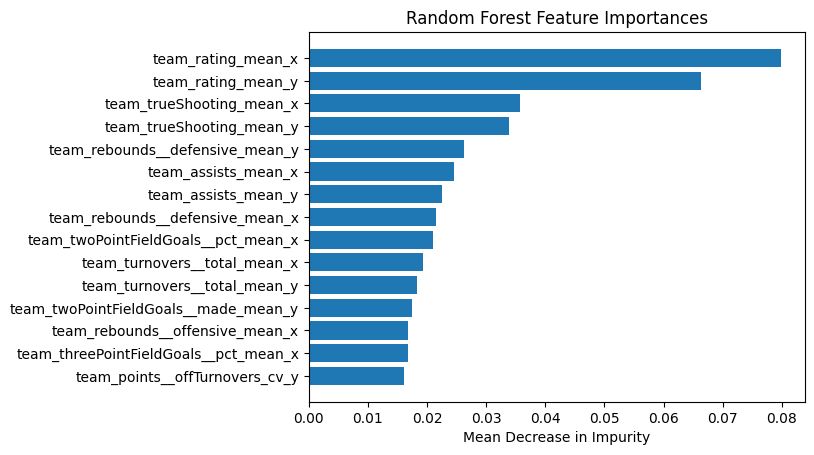

In [ ]:
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)
top = importances.head(15)

plt.barh(top.index[::-1], top.values[::-1])
plt.title("Random Forest Feature Importances")
plt.xlabel("Mean Decrease in Impurity")
plt.show()


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix
)

# binary predictions (threshold = 0.5)
y_pred = (p_hat >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Log loss:", log_loss(y_test, p_hat))
print("ROC AUC:", roc_auc_score(y_test, p_hat))
print("Brier score:", brier_score_loss(y_test, p_hat))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.679160419790105
Log loss: 0.5883397751704548
ROC AUC: 0.7559549135212161
Brier score: 0.20167098085208254

Confusion matrix:
[[483 210]
 [218 423]]


##### XGBoost Classifier

In [ ]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split

# features + target
X = data.select(pl.exclude(['home_win'])).to_pandas()
y = data["home_win"].to_pandas()

# 90/10 split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

# XGBoost classifier
xgb_clf = xgb.XGBClassifier(
    objective="binary:logistic",   # logistic loss
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# fit
xgb_clf.fit(X_train, y_train)

# ------------------------
# logits (raw margins)
# ------------------------
logits = xgb_clf.predict(
    X_test,
    output_margin=True   # <-- THIS is what you want
)

# ------------------------
# probabilities (optional)
# ------------------------
p_hat = 1 / (1 + np.exp(-logits))


In [ ]:
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, brier_score_loss

y_pred = (p_hat >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Log loss:", log_loss(y_test, p_hat))
print("ROC AUC:", roc_auc_score(y_test, p_hat))
print("Brier score:", brier_score_loss(y_test, p_hat))


Accuracy: 0.676911544227886
Log loss: 0.5975883460111322
ROC AUC: 0.7466238043461131
Brier score: 0.20576485020568927


#### Getting Inference Data

Pull data for this current season from all the conferences

In [ ]:
import os
import time
import requests
import pandas as pd
API_KEY = "s4nBZ6DTsw+JiD+RX3CiqQG69Jpw0Sc6i98UawZSJdDYgpOnhdr8C4Z6SSy1r6JJ"

BASE_URL = "https://api.collegebasketballdata.com"
headers = {"Authorization": f"Bearer {API_KEY}"}

SEASON = 2026
SEASON_TYPES = ["regular", "postseason"]  # keep both if you want conference tourney games too

def get_json(url, params):
    r = requests.get(url, headers=headers, params=params, timeout=30)
    r.raise_for_status()
    return r.json()

# 1) Get all conferences (AQ conferences = essentially all D-I conferences returned here)
confs = get_json(f"{BASE_URL}/conferences", params={})

def conf_key(c):
    # pick the best identifier field the API gives you
    return c.get("abbreviation") or c.get("conference") or c.get("name")

conf_ids = sorted({conf_key(c) for c in confs if conf_key(c)})

# 2) Pull games/teams for each conference
all_rows = []
for conf in conf_ids:
    for season_type in SEASON_TYPES:
        params = {
            "season": SEASON,
            "conference": conf,
            "seasonType": season_type,  # if empty results, try "season_type"
        }

        try:
            rows = get_json(f"{BASE_URL}/games/teams", params=params)
            for row in rows:
                row["conference_query"] = conf
                row["seasonType_query"] = season_type
            all_rows.extend(rows)
        except requests.HTTPError as e:
            print(f"[WARN] failed conf={conf}, seasonType={season_type}: {e}")

        time.sleep(0.05)

df = pd.json_normalize(all_rows)

# 3) De-dupe: /games/teams often returns one row per team per game
# Prefer a real game id if present; otherwise de-dupe by (date, home, away).
if "gameId" in df.columns:
    # if it's one row per team, gameId alone should collapse to 1 row/game
    df_games = df.drop_duplicates(subset=["gameId"]).copy()
elif "id" in df.columns:
    df_games = df.drop_duplicates(subset=["id"]).copy()
else:
    # common field names to try
    key = [c for c in ["date", "startDate", "homeTeam", "awayTeam"] if c in df.columns]
    if len(key) >= 3:
        df_games = df.drop_duplicates(subset=key).copy()
    else:
        # last resort: keep everything
        df_games = df.copy()

print("rows (team-level):", df.shape)
print("rows (game-level):", df_games.shape)
# print(df_games.head())


rows (team-level): (11912, 98)
rows (game-level): (6231, 98)


In [ ]:
df.columns

Index(['gameId', 'season', 'seasonLabel', 'seasonType', 'tournament',
       'startDate', 'startTimeTbd', 'teamId', 'team', 'conference', 'teamSeed',
       'opponentId', 'opponent', 'opponentConference', 'opponentSeed',
       'neutralSite', 'isHome', 'conferenceGame', 'gameType', 'notes',
       'gameMinutes', 'pace', 'conference_query', 'seasonType_query',
       'teamStats.possessions', 'teamStats.assists', 'teamStats.steals',
       'teamStats.blocks', 'teamStats.trueShooting', 'teamStats.rating',
       'teamStats.gameScore', 'teamStats.points.total',
       'teamStats.points.byPeriod', 'teamStats.points.largestLead',
       'teamStats.points.fastBreak', 'teamStats.points.inPaint',
       'teamStats.points.offTurnovers', 'teamStats.twoPointFieldGoals.made',
       'teamStats.twoPointFieldGoals.attempted',
       'teamStats.twoPointFieldGoals.pct',
       'teamStats.threePointFieldGoals.made',
       'teamStats.threePointFieldGoals.attempted',
       'teamStats.threePointFieldGoal

In [ ]:
df['conference'].unique()

array(['A-10', 'ACC', 'ASUN', 'Am. East', 'American', 'Big 12',
       'Big East', 'Big Sky', 'Big South', 'Big Ten', 'Big West', 'CAA',
       'CUSA', 'Horizon', 'Ivy', 'MAAC', 'MAC', 'MEAC', 'MVC',
       'Mountain West', 'NEC', 'OVC', 'Patriot', 'SEC', 'SWAC', 'SoCon',
       'Southland', 'Summit', 'Sun Belt', 'WAC', 'WCC'], dtype=object)

In [ ]:
df[df['conference']=='Big East']['team'].unique()

array(['Georgetown', "St. John's", 'UConn', 'Xavier', 'Providence',
       'Seton Hall', 'DePaul', 'Marquette', 'Villanova', 'Butler',
       'Creighton'], dtype=object)

In [ ]:
march_madness_2025_teams = [
    "Auburn",
    "Alabama",
    "Arizona",
    "Baylor",
    "BYU",
    "Creighton",
    "Duke",
    "Houston",
    "Illinois",
    "Iowa State",
    "Kansas",
    'Miami (OH)',
    'Gonzaga',
    'High Point',
    'VCU',
    'Virginia',
    'Nebraska',
    'North Carolina',
    'Maryland',
    'Michigan',
    'Howard',
    'Georgia',
    'Texas Tech',
    'Akron',
    'Hofstra',
    'Tennessee',
    'SMU',
    'Kentucky',
    'Santa Clara',
    'Florida',
    'Clemson',
    'Iowa',
    'Vanderbilt',
    'Troy',
    'Idaho',
    'LIU',
    'Villanova',
    'Wisconsin',
    'Arkansas',
    'Texas',
    'Gonzaga',
    'Missouri',
    'Purdue',
    'Queens',
    'Duke',
    'Siena',
    'TCU',
    'Northern Iowa',
    'Kansas',
    'Louisville',
    'UCLA',
    'Furman',
    'UMBC',
    'Saint Louis',
    'SMU',
    'Wright State',
    'Tennessee State',
    'Prairie View A&M',
    'Lehigh',
    'McNeese',
    'Pennsylvania',
    "Saint Mary's",
    'Texas A&M',
    'Utah State',
    "Hawai'i",
    'NC State',
    'Kennesaw State',
    'Ohio State',
    'Miami',
    "St. John's",
    'California Baptist',
    'South Florida',
    'Michigan State',
    'North Dakota State',
    'UCF',
    'UConn'



]





In [ ]:
len(march_madness_2025_teams)  # 68
# len(set(march_madness_2025_teams))  # 68


76

Filter down to the teams in the list above

In [ ]:
df_mm = df[df["team"].isin(march_madness_2025_teams)].copy()

In [ ]:
df_mm=df_mm[df_mm['seasonType']=='regular']

In [ ]:
import numpy as np
import pandas as pd

# these are what we group by
GROUP_KEYS = ["teamId",'team', "season"]

PACE_COL_CANDIDATES = ["pace", "teamStats.pace", "teamStats.possessions"]  # pick what exists

# Preferred NEW schema (dot-labeled)
STAT_COLS_NEW = [
    "teamStats.assists",
    "teamStats.steals",
    "teamStats.blocks",
    "teamStats.trueShooting",
    "teamStats.rating",
    "teamStats.points.fastBreak",
    "teamStats.points.inPaint",
    "teamStats.points.offTurnovers",
    "teamStats.twoPointFieldGoals.made",
    "teamStats.twoPointFieldGoals.pct",
    "teamStats.threePointFieldGoals.made",
    "teamStats.threePointFieldGoals.pct",
    "teamStats.freeThrows.made",
    "teamStats.freeThrows.pct",
    "teamStats.turnovers.total",
    "teamStats.rebounds.offensive",
    "teamStats.rebounds.defensive",
    "teamStats.fourFactors.freeThrowRate",
]

# Optional: if you still sometimes have the OLD schema
STAT_COLS_OLD = [
    "team_assists",
    "team_steals",
    "team_blocks",
    "team_trueShooting",
    "team_rating",
    "team_points__fastBreak",
    "team_points__inPaint",
    "team_points__offTurnovers",
    "team_twoPointFieldGoals__made",
    "team_twoPointFieldGoals__pct",
    "team_threePointFieldGoals__made",
    "team_threePointFieldGoals__pct",
    "team_freeThrows__made",
    "team_freeThrows__pct",
    "team_turnovers__total",
    "team_rebounds__offensive",
    "team_rebounds__defensive",
    "team_fourFactors__freeThrowRate",
]

def first_existing(cols, df_cols):
    for c in cols:
        if c in df_cols:
            return c
    return None

# choose pace column that exists
PACE_COL = first_existing(PACE_COL_CANDIDATES, df.columns)

# choose which stats exist (prefer new)
existing_new = [c for c in STAT_COLS_NEW if c in df.columns]
existing_old = [c for c in STAT_COLS_OLD if c in df.columns]

STAT_COLS = existing_new if len(existing_new) > 0 else existing_old
if PACE_COL is None:
    raise ValueError("Couldn't find a pace column. Add the correct name to PACE_COL_CANDIDATES.")
if len(STAT_COLS) == 0:
    raise ValueError("Couldn't find any stat columns in either schema. Check df.columns.")

# 1) aggregate mean/std
agg_spec = {PACE_COL: ["mean", "std"], **{c: ["mean", "std"] for c in STAT_COLS}}

out = (
    df.groupby(GROUP_KEYS, dropna=False)
      .agg(agg_spec)
)

# 2) flatten columns: (col, stat) -> col_stat
out.columns = [f"{c}_{stat}" for (c, stat) in out.columns]
out = out.reset_index()

# 3) add CVs (std / mean)
for c in STAT_COLS + [PACE_COL]:
    mean_col = f"{c}_mean"
    std_col  = f"{c}_std"
    cv_col   = f"{c}_cv"
    out[cv_col] = np.where(out[mean_col].abs() > 0, out[std_col] / out[mean_col], np.nan)

# optional: keep "pace_cv" name stable even if pace column is "teamStats.pace"
out["pace_cv"] = out[f"{PACE_COL}_cv"]

# 4) drop std cols if you want
out = out.loc[:, ~out.columns.str.endswith("_std")]


In [ ]:
out_pl=pl.DataFrame(out) #make it polars

#### Scaling by SOS (scraping KenPom)

In [ ]:
weight=1

In [ ]:
async with AsyncSession() as session:
    response = await session.get('https://kenpom.com/', impersonate='chrome')
    soup = BeautifulSoup(response.text, 'html.parser')
    table = soup.find('table', id='ratings-table')

In [ ]:
import pandas as pd
from bs4 import BeautifulSoup

def parse_kenpom_table(table):
    rows = []
    for tr in table.find('tbody').find_all('tr'):
        row = []
        for td in tr.find_all('td'):
            row.append(td.get_text(strip=True))
        if row:
            rows.append(row)
    return pd.DataFrame(rows)

df_ken_pom = parse_kenpom_table(table)
ken_pom_pl=pl.DataFrame(df_ken_pom)
ken_pom_pl=ken_pom_pl.select(['1','15','17'])
ken_pom_pl=ken_pom_pl.with_columns((pl.col('15').cast(pl.Float32)-pl.col('17').cast(pl.Float32)).alias('NetSos'))
ken_pom_pl=ken_pom_pl.select(['1','NetSos'])
ken_pom_pl=ken_pom_pl.rename({'1':'Team'})

In [ ]:
#z-score the sos
ken_pom_pl=ken_pom_pl.with_columns(
    ((pl.col('NetSos')-pl.col('NetSos').mean())/pl.col('NetSos').std())
    .alias('sos_z')
)

In [ ]:
#make a sos weighting scheme where it weights the high sos as very good and vice versa
ken_pom_pl=ken_pom_pl.with_columns(
    pl.when(pl.col('sos_z')<0)
    .then(1/((np.abs(pl.col('sos_z'))**weight)+1))
    .otherwise((pl.col('sos_z')**weight)+1)
    .alias('sos_weight')

)

In [ ]:
ken_pom_pl.filter(pl.col('Team')=='BYU')

Team,NetSos,sos_z,sos_weight
str,f32,f32,f32


In [ ]:


ken_pom_pl = ken_pom_pl.with_columns(
    pl.col("Team").str.replace_all(r"\d+", "").alias("Team")
)



In [ ]:
ken_pom_pl.filter(pl.col('Team')=='Purdue')

Team,NetSos,sos_z,sos_weight
str,f32,f32,f32
"""Purdue""",15.900002,2.090916,3.090916


Making the team names consistent across the two df

In [ ]:
ken_pom_pl = ken_pom_pl.with_columns(
    pl.when(pl.col("Team") == "Miami OH")
    .then(pl.lit("Miami (OH)"))
    .when(pl.col("Team") == "Ohio St.")
    .then(pl.lit("Ohio State"))
    .when(pl.col('Team')=='Cal Baptist')
    .then(pl.lit('California Baptist'))
    .when(pl.col("Team") == "Michigan St.")
    .then(pl.lit('Michigan State'))
    .when(pl.col("Team") == "North Dakota St.")
    .then(pl.lit('North Dakota State'))
    .when(pl.col("Team") == "Connecticut")
    .then(pl.lit('UConn'))
    .when(pl.col("Team") == "Utah St.")
    .then(pl.lit('Utah State'))
    .when(pl.col("Team") == "Hawaii")
    .then(pl.lit("Hawai'i"))
    .when(pl.col("Team") == "N.C. State")
    .then(pl.lit("NC State"))
    .when(pl.col("Team") == "Kennesaw St.")
    .then(pl.lit("Kennesaw State"))
    .when(pl.col("Team") == "Miami FL")
    .then(pl.lit("Miami"))
    .when(pl.col("Team") == "Penn")
    .then(pl.lit("Pennsylvania"))
    .when(pl.col("Team") == "Wright St.")
    .then(pl.lit("Wright State"))
    .when(pl.col("Team") == "Iowa St.")
    .then(pl.lit("Iowa State"))
    .when(pl.col("Team") == "Tennessee St.")
    .then(pl.lit("Tennessee State"))
    .otherwise(pl.col("Team"))
    .alias("Team")
)

#### Running Inference

In [ ]:
team1=input('Input first team: ')
team2=input('Input second team: ')

team1_df=out_pl.filter(pl.col('team')==team1)
team2_df=out_pl.filter(pl.col('team')==team2)


Input first team: Miami (OH)


In [ ]:
def rename_team_cols(cols):
    out = {}
    for c in cols:
        new = c

        # handle pace separately
        if c in {"pace_mean", "pace_cv"}:
            out[c] = f"{c}_x"
            continue

        # only rename teamStats columns
        if c.startswith("teamStats."):
            new = c.replace("teamStats.", "team_", 1)

            # split off suffix (_mean or _cv)
            if new.endswith("_mean"):
                base = new[:-5]
                suffix = "_mean_x"
            elif new.endswith("_cv"):
                base = new[:-3]
                suffix = "_cv_x"
            else:
                base = new
                suffix = "_x"

            # replace remaining dots with double underscore
            base = base.replace(".", "__")

            new = base + suffix

        out[c] = new

    return out


rename_map = rename_team_cols(team1_df.columns)

team1_df = team1_df.rename(rename_map)
team1_df=team1_df.select(pl.exclude(['teamId','team','season']))


In [ ]:
def rename_team_cols_y(cols):
    out = {}
    for c in cols:
        new = c

        # handle pace separately
        if c in {"pace_mean", "pace_cv"}:
            out[c] = f"{c}_y"
            continue

        # only rename teamStats columns
        if c.startswith("teamStats."):
            new = c.replace("teamStats.", "team_", 1)

            # split off suffix (_mean or _cv)
            if new.endswith("_mean"):
                base = new[:-5]
                suffix = "_mean_y"
            elif new.endswith("_cv"):
                base = new[:-3]
                suffix = "_cv_y"
            else:
                base = new
                suffix = "_y"

            # replace remaining dots with double underscore
            base = base.replace(".", "__")

            new = base + suffix

        out[c] = new

    return out


rename_map = rename_team_cols_y(team2_df.columns)

team2_df = team2_df.rename(rename_map)
team2_df=team2_df.select(pl.exclude(['teamId','team','season']))


Now that we have the two we need to concat

In [ ]:
infer_df = pl.concat([team1_df, team2_df], how="horizontal") #make the normal one where team1 is first


infer_df = infer_df.with_columns(
    pl.lit(1).alias("seasonType")
).select(
    ["seasonType"] + infer_df.columns
)

In [ ]:
team2_df = team2_df.rename({
    c: c.replace("_y", "_x") for c in team2_df.columns
})


team1_df = team1_df.rename({
    c: c.replace("_x", "_y") for c in team1_df.columns
})


infer2_df=pl.concat([team2_df, team1_df], how="horizontal") #make it backwards too, just to be consistent

infer2_df = infer2_df.with_columns(
    pl.lit(1).alias("seasonType")
).select(
    ["seasonType"] + infer2_df.columns
)

In [ ]:
ordered_cols = list(X_train.columns)

infer_df = infer_df.select(ordered_cols)
infer2_df=infer2_df.select(ordered_cols)
infer_df=infer_df.to_pandas()
infer2_df=infer2_df.to_pandas()

In [ ]:
y_prob = pipe_logistic.predict_proba(infer_df)[:, 1]

In [ ]:
t1_1=y_prob.item()
t2_2=1-t1_1

In [ ]:
y_prob_2 = pipe_logistic.predict_proba(infer2_df)[:, 1]

In [ ]:
t2_1=y_prob_2.item()
t1_2=1-t2_1

In [ ]:
team1_win_pct=(t1_1+t1_2)/2
team2_win_pct=(t2_1+t2_2)/2

In [ ]:
team1_sos_weight=ken_pom_pl.filter(pl.col('Team')==f'{team1}').select('sos_weight').item()
team2_sos_weight=ken_pom_pl.filter(pl.col('Team')==f'{team2}').select('sos_weight').item()

In [ ]:
team1_win_pct=team1_win_pct*team1_sos_weight
team2_win_pct=team2_win_pct*team2_sos_weight


In [ ]:
#standardize it to sum to 1
total=team1_win_pct+team2_win_pct
team1_win_pct=team1_win_pct/total
team2_win_pct=team2_win_pct/total

In [ ]:
plt.figure(figsize=(10,6))
values = [team1_win_pct, team2_win_pct]
labels = [team1, team2]
plt.bar(labels, values,color=["tab:blue", "tab:red"])
plt.ylabel("Average Win Percentage")
plt.title("Win Percentage by Team")
plt.xlabel('Team')
plt.show()